Dataset Shape: (569, 30)
Classes: ['malignant' 'benign']
Training Samples: 398
Testing Samples: 171

===== Decision Tree =====
Training Accuracy: 1.0
Test Accuracy: 0.9415204678362573

Classification Report:

              precision    recall  f1-score   support

   malignant       0.90      0.95      0.92        63
      benign       0.97      0.94      0.95       108

    accuracy                           0.94       171
   macro avg       0.93      0.94      0.94       171
weighted avg       0.94      0.94      0.94       171


Confusion Matrix:

[[ 60   3]
 [  7 101]]


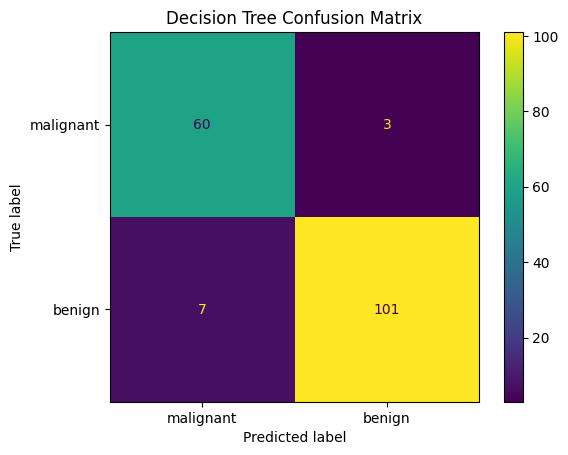

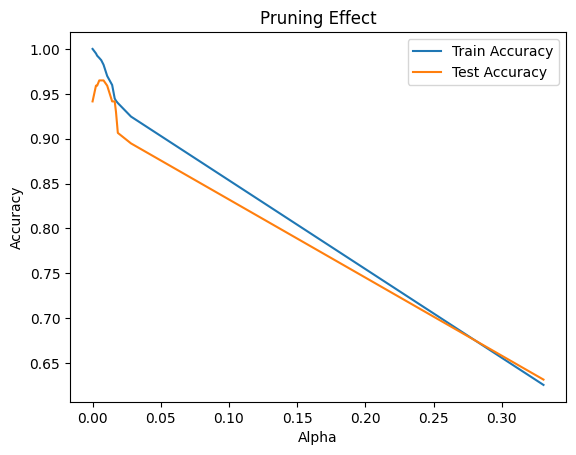


Pruned Tree Accuracy: 0.9649122807017544

Random Forest Accuracy: 0.9707602339181286

AdaBoost Accuracy: 0.9707602339181286

Model Comparison:

                  Model  Accuracy
0         Decision Tree  0.941520
1  Pruned Decision Tree  0.964912
2         Random Forest  0.970760
3              AdaBoost  0.970760


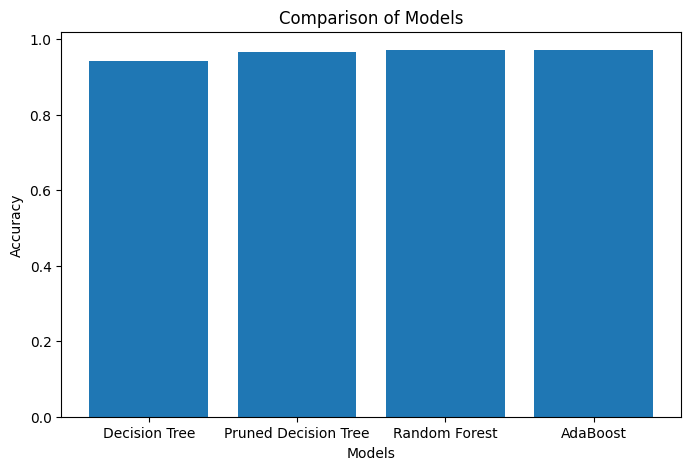


Cross Validation Scores:

Decision Tree CV Accuracy: 0.9173420276354604
Random Forest CV Accuracy: 0.9560937742586555
AdaBoost CV Accuracy: 0.9683744760130415


In [1]:
# ============================================
# Install Required Libraries
# (Run in terminal OR use !pip in notebook)
# ============================================

# !pip install pandas numpy scikit-learn matplotlib


# ============================================
# STEP 1: Import Libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.tree import (
    DecisionTreeClassifier,
    DecisionTreeRegressor,
    plot_tree
)

from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_squared_error,
    r2_score
)


# ============================================
# STEP 2: Load Breast Cancer Dataset
# ============================================

data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset Shape:", X.shape)

print("Classes:", data.target_names)


# ============================================
# STEP 3: Split Dataset
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))


# ============================================
# STEP 4: Decision Tree Classifier
# ============================================

dt_classifier = DecisionTreeClassifier(
    random_state=42
)

dt_classifier.fit(X_train, y_train)

y_train_pred = dt_classifier.predict(X_train)

y_test_pred = dt_classifier.predict(X_test)


# ============================================
# STEP 5: Accuracy
# ============================================

print("\n===== Decision Tree =====")

print(
    "Training Accuracy:",
    accuracy_score(y_train, y_train_pred)
)

print(
    "Test Accuracy:",
    accuracy_score(y_test, y_test_pred)
)


# ============================================
# STEP 6: Classification Report
# ============================================

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=data.target_names
    )
)


# ============================================
# STEP 7: Confusion Matrix
# ============================================

cm = confusion_matrix(y_test, y_test_pred)

print("\nConfusion Matrix:\n")

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot()

plt.title("Decision Tree Confusion Matrix")

plt.show()


# ============================================
# STEP 9: Pruning
# ============================================

path = dt_classifier.cost_complexity_pruning_path(
    X_train,
    y_train
)

ccp_alphas = path.ccp_alphas

trees = []

for alpha in ccp_alphas:

    tree = DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=alpha
    )

    tree.fit(X_train, y_train)

    trees.append(tree)


train_scores = [
    accuracy_score(
        y_train,
        t.predict(X_train)
    )
    for t in trees
]

test_scores = [
    accuracy_score(
        y_test,
        t.predict(X_test)
    )
    for t in trees
]


# ============================================
# STEP 10: Accuracy vs Alpha Graph
# ============================================

plt.plot(
    ccp_alphas,
    train_scores,
    label="Train Accuracy"
)

plt.plot(
    ccp_alphas,
    test_scores,
    label="Test Accuracy"
)

plt.xlabel("Alpha")

plt.ylabel("Accuracy")

plt.legend()

plt.title("Pruning Effect")

plt.show()


# ============================================
# STEP 11: Pruned Tree
# ============================================

pruned_tree = DecisionTreeClassifier(
    ccp_alpha=0.01,
    random_state=42
)

pruned_tree.fit(X_train, y_train)

pruned_predictions = pruned_tree.predict(X_test)

print(
    "\nPruned Tree Accuracy:",
    accuracy_score(y_test, pruned_predictions)
)


# ============================================
# STEP 12: Random Forest
# ============================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print(
    "\nRandom Forest Accuracy:",
    accuracy_score(y_test, rf_predictions)
)


# ============================================
# STEP 13: AdaBoost
# ============================================

stump = DecisionTreeClassifier(max_depth=1)

ada_model = AdaBoostClassifier(
    estimator=stump,
    n_estimators=50,
    random_state=42
)

ada_model.fit(X_train, y_train)

ada_predictions = ada_model.predict(X_test)

print(
    "\nAdaBoost Accuracy:",
    accuracy_score(y_test, ada_predictions)
)


# ============================================
# STEP 14: Model Comparison
# ============================================

comparison = pd.DataFrame({

    "Model": [
        "Decision Tree",
        "Pruned Decision Tree",
        "Random Forest",
        "AdaBoost"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_test_pred),
        accuracy_score(y_test, pruned_predictions),
        accuracy_score(y_test, rf_predictions),
        accuracy_score(y_test, ada_predictions)
    ]
})

print("\nModel Comparison:\n")

print(comparison)


# ============================================
# STEP 15: Bar Graph
# ============================================

plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.title("Comparison of Models")

plt.show()


# ============================================
# STEP 16: Cross Validation
# ============================================

dt_score = cross_val_score(
    dt_classifier,
    X,
    y,
    cv=5
).mean()

rf_score = cross_val_score(
    rf_model,
    X,
    y,
    cv=5
).mean()

ada_score = cross_val_score(
    ada_model,
    X,
    y,
    cv=5
).mean()

print("\nCross Validation Scores:\n")

print("Decision Tree CV Accuracy:", dt_score)

print("Random Forest CV Accuracy:", rf_score)

print("AdaBoost CV Accuracy:", ada_score)